In [1]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuração visual
sns.set_theme(style="whitegrid")

# 1. Carregando os dados
# Assumindo que você está rodando o notebook de dentro da pasta 'notebooks/'
df = pd.read_csv('../data/processed/consumo_sao_paulo.csv')

# 2. Seleção de Variáveis (Feature Selection)
# Lembra do nosso heatmap? Vamos remover temp_media e temp_min para evitar multicolinearidade
# Também não vamos usar a data exata para o modelo não decorar o calendário
features = ['temp_max', 'chuva_mm', 'fim_de_semana', 'mes']
target = 'consumo_mil_litros'

X = df[features]
y = df[target]

# 3. Divisão de Treino e Teste (O padrão ouro da modelagem)
# Vamos usar 80% dos dados para ensinar os modelos e 20% "escondidos" para testá-los
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do Treino: {X_train.shape[0]} dias")
print(f"Tamanho do Teste: {X_test.shape[0]} dias\n")

# ==========================================
# 4. Treinamento dos Modelos
# ==========================================

# Modelo 1: Regressão Linear
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
previsoes_lr = modelo_lr.predict(X_test)

# Modelo 2: Random Forest
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
previsoes_rf = modelo_rf.predict(X_test)

# ==========================================
# 5. Avaliação de Performance (Métricas de Negócio)
# ==========================================
# R² (R-Quadrado) responde: "Quanto da variação das vendas o modelo consegue explicar?" (O máximo é 1.0)
# MAE (Erro Absoluto Médio) responde: "Em média, quantos mil litros o modelo erra por dia?"

print("--- REGRESSÃO LINEAR ---")
print(f"R²: {r2_score(y_test, previsoes_lr):.4f}")
print(f"Erro Médio (MAE): {mean_absolute_error(y_test, previsoes_lr):.2f} mil litros\n")

print("--- RANDOM FOREST ---")
print(f"R²: {r2_score(y_test, previsoes_rf):.4f}")
print(f"Erro Médio (MAE): {mean_absolute_error(y_test, previsoes_rf):.2f} mil litros")

Tamanho do Treino: 292 dias
Tamanho do Teste: 73 dias

--- REGRESSÃO LINEAR ---
R²: 0.7411
Erro Médio (MAE): 1.98 mil litros

--- RANDOM FOREST ---
R²: 0.6795
Erro Médio (MAE): 2.08 mil litros


--- IMPACTO NO NEGÓCIO (REGRESSÃO LINEAR) ---
        Fator  Impacto (Mil Litros)
fim_de_semana              5.232861
     temp_max              0.677740
          mes              0.140401
     chuva_mm             -0.043003

Leitura Estratégica:
- Cada 1ºC a mais na temperatura máxima gera, em média, 0.68 mil litros a mais em vendas.


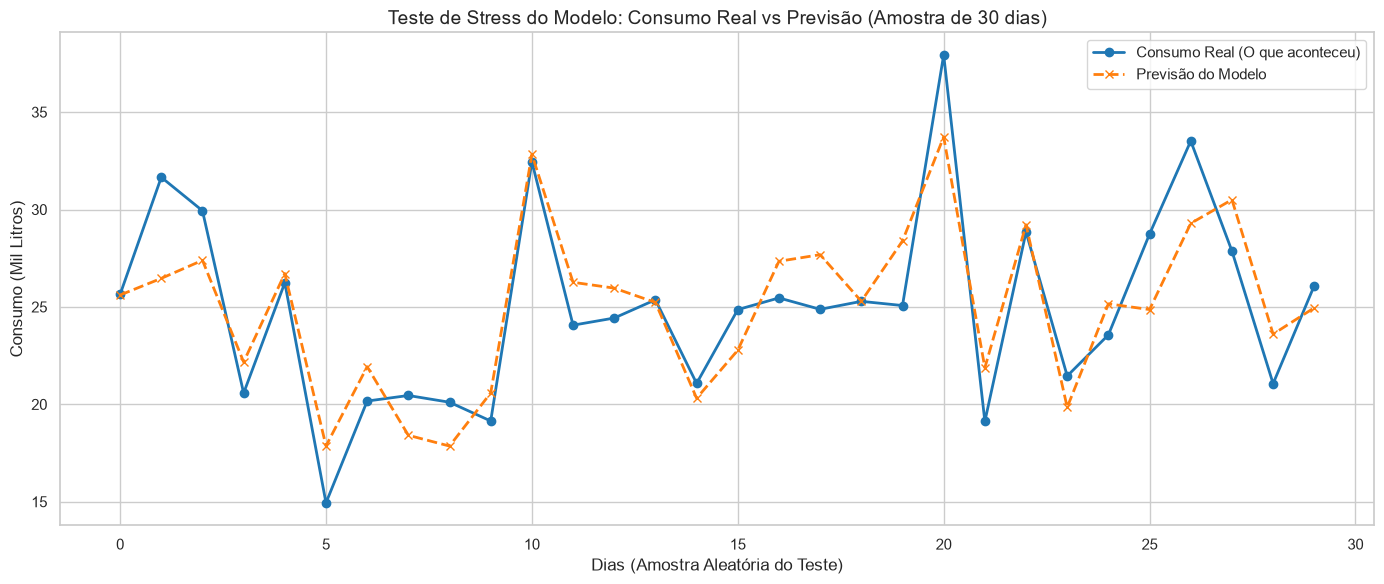

In [3]:

# ==========================================
# 6. Interpretabilidade (O Peso de cada Alavanca)
# ==========================================
# Extraindo os coeficientes do modelo vencedor (Regressão Linear)
coeficientes = pd.DataFrame({
    'Fator': features,
    'Impacto (Mil Litros)': modelo_lr.coef_
}).sort_values(by='Impacto (Mil Litros)', ascending=False)

print("--- IMPACTO NO NEGÓCIO (REGRESSÃO LINEAR) ---")
print(coeficientes.to_string(index=False))
print("\nLeitura Estratégica:")
print(f"- Cada 1ºC a mais na temperatura máxima gera, em média, {coeficientes.loc[coeficientes['Fator']=='temp_max', 'Impacto (Mil Litros)'].values[0]:.2f} mil litros a mais em vendas.")

# ==========================================
# 7. Visualização de Performance (Real vs Previsto)
# ==========================================
# Selecionar uma amostra de 30 dias para o gráfico não ficar demasiado denso
df_comparacao = pd.DataFrame({'Real': y_test, 'Previsto': previsoes_lr}).reset_index(drop=True)
amostra = df_comparacao.head(30)

plt.figure(figsize=(14, 6))
plt.plot(amostra.index, amostra['Real'], label='Consumo Real (O que aconteceu)', marker='o', color='#1f77b4', linewidth=2)
plt.plot(amostra.index, amostra['Previsto'], label='Previsão do Modelo', marker='x', color='#ff7f0e', linestyle='--', linewidth=2)

plt.title('Teste de Stress do Modelo: Consumo Real vs Previsão (Amostra de 30 dias)', fontsize=14)
plt.ylabel('Consumo (Mil Litros)')
plt.xlabel('Dias (Amostra Aleatória do Teste)')
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/05_real_vs_previsto.png", dpi=300, bbox_inches='tight')
plt.show()

## 📌 Conclusão Executiva e Impactos para o Negócio

Este projeto demonstrou como a Ciência de Dados pode transformar variáveis climáticas e de calendário em **previsibilidade logística**. Ao prever a demanda diária com um R² de 74% e uma margem de erro (MAE) restrita a apenas 1.98 mil litros, a cervejaria ganha uma ferramenta quantitativa para otimização de estoque e redução de capital imobilizado.

### Principais Descobertas Quantitativas:
Ao "abrir a caixa" do modelo de Regressão Linear, extraímos os pesos exatos das nossas alavancas de venda:

* **O Prêmio do Fim de Semana:** É o maior motor de vendas da operação. O simples fato de o dia ser um fim de semana eleva o patamar base de consumo em **5.23 mil litros**, independentemente de qualquer outro fator.
* **A Alavanca Térmica:** O calor impulsiona o consumo de forma constante e previsível. Para cada **1ºC a mais** na temperatura máxima diária, o negócio deve preparar o estoque para escoar **680 litros a mais** (0.68 mil litros).
* **O Mito da Chuva:** Contrariando a intuição de muitos gestores, a chuva apresentou o menor peso no modelo (-0.04). Um fim de semana chuvoso e quente continuará demandando alta capacidade logística.

